# Design Project - WWTP N2O Emissions Modelling 

## Part I -  Data Preprocessing & Exploration

### Notes on Methodological Choices 

Methodological choices made to be applied during the preprocessing:

**I. Handling negative values:**

- For concentration measures with negative values (N2O, DO, NH4 and NO3) apply a linear shift by magnitude of least valued observation.

- For inflow: significant negative outliers (mininimum value of -5572.45) - 

*Method for dealing with inflow negative outliers to be determined - potentially interpolate since negative values only represent ~0.022% of all observations.*

**II. Resampling Frequency:** 

Downsampling using a 10 minute interval. 

**III. Missing values:***

During the preprocessing, an initial data gap size threhold of 1 day is applied to identify sub-segments in the data and to eliminate the largest gaps in the data for which methods such as interpolation would not be appropriate. 

The initial 1 day threshold includes considers periods where data is missing for the following variables: t1_n2o, t1_do, t1_airflow, t1_nh4, t1_no3, and t1_temp. 

Further in processing the data, a general threshold for the size of the gap in data will be set at 6 hours. For gaps in the observations < 6 hours, we will apply the most appropriate method - to be determined (interpolation, smoothing through resampling, etc.).


### Questions

**Q1:** Timestamp alignment: currently approx. ~50% of the data is on even minutes and the other 50% on odd minutes, so it is not split evenly in 2 minute intervals. Need to decide method for handling the misalignment between timestamps (see below): 

Option 1: Shift all even minute observations to odd minutes (see below) - doesn't seem to change overall distribution of data, but this step could potentially be left out?

Option 2: Resample directly (no alignment before) - see analysis for 2 min and 10 min resampling 
(Note: 2 min resampling only used for EDA purposes, the actual 10 min frequency resampling is done on the raw data after basic cleaning)

**Q2:** Outlier removal / handling 
Before resampling: remove only outliers that are obviously physically impossible before resampling? (negative values handled as a part of preprocessing)
Once resampled, outlier analysis should be done on a monthly basis (extreme values change based on the temporal period)

**Q3:** 'Flat lining' sensors? Keep in data + add explanation (separate outlier analysis doc) 

### Preprocessing pipeline - outline (draft) :


**I. Initial preprocessing steps:**

- Review data type, df shape and general descriptive statistics ✅
- Datetime: set as index ✅
- Remove duplicate values with equal timestamps ✅
- Drop tank 2 observations (full data only available for tank 1) ✅
- Clean variable names ✅
- Handle negative values (pre-global / local descriptive stats) ✅
- Resample / align timestamps: 
Remove extreme outliers (only N2O) ✅
Option 1: align timestamps then resample to 10 min frequency ✅
Option 2: directly resample to 10 min frequency ✅

**II. Exploratory Data Analysis (EDA):**

**Global:**

- Global descriptive statistics & data analysis

**EDA for sub-segment of dataset:** 

- Apply threshold (initial 1 day) to remove largest gaps in the dataset and identify key segments 
- Descriptive statistics / data analysis for selected segment of the data 

**III.  Resampling frequency**

- Resample after cleaning - 2min -> 10 min frequency 

**IV. Outlier detection & removal:**

- Identify extreme values across monthly intervals / seasons - can shift significantly depending on period considered 
- Method for outlier removal?

**V. Feature engineering:** 

In [8]:
#Import relevant libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import gaussian_kde
from scipy.stats import ks_2samp

import warnings
warnings.filterwarnings('ignore')

#Display settings 
pd.set_option('display.max_columns', None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


#### Upload data & initial checks 

In [9]:
#Upload csv file and check data types
#Note: file is too large to upload to GitHub, change the file path to your local directory to run the code
df = pd.read_csv("E:\\2025-2026\CIVE70088\Coursework\\aved_raw.csv") 
df.head() 

,time,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,BIOLOGY.LINE 3 TANK 1.NO3 quality,BIOLOGY.LINE 3 TANK 1.O2 value,BIOLOGY.LINE 3 TANK 1.O2 quality,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1.SS value,BIOLOGY.LINE 3 TANK 1.SS quality,BIOLOGY.LINE 3 TANK 1.TEMPERATURE value,BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 2.O2 value,BIOLOGY.LINE 3 TANK 2.O2 quality,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 2.SS value,BIOLOGY.LINE 3 TANK 2.SS quality,BIOLOGY.LINE 3 TANK 2.TEMPERATURE value,BIOLOGY.LINE 3 TANK 2.TEMPERATURE quality,BIOLOGY.LINE 3.PHASECODE.SETPOINT value,BIOLOGY.LINE 3.PHASECODE.SETPOINT quality,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality,BIOLOGY.LINE 3 TANK 1.PO4 value,BIOLOGY.LINE 3 TANK 1.PO4 quality,INLET.Q value,INLET.Q quality,INLET.STATE.SWM INLET FLOW value,INLET.STATE.SWM INLET FLOW quality
0,2022-06-12 00:01:00+02:00,26829.375000,1.0,NaN,NaN,0.700231,0.0,1.66608,0.0,0.074907,0.0,0.058955,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.525374,1.0,NaN,NaN,NaN,NaN,1.384549,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.647483,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
1,2022-06-12 00:02:00+02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.238239,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.507085,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2,2022-06-12 00:03:00+02:00,29626.341797,1.0,NaN,NaN,0.697917,0.0,1.52727,0.0,0.074907,0.0,0.079933,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.536805,1.0,NaN,NaN,NaN,NaN,1.673177,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.594784,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
3,2022-06-12 00:04:00+02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.154271,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.432644,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
4,2022-06-12 00:05:00+02:00,28605.208984,1.0,NaN,NaN,0.656829,0.0,1.43633,0.0,0.056901,0.0,0.330223,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.509847,0.0,NaN,NaN,NaN,NaN,2.121311,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.631665,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


In [10]:
#Check shape of dataset 
shape = df.shape
print(f"The dataset contains {shape[0]} rows and {shape[1]} columns.")

The dataset contains 906815 rows and 49 columns.


In [11]:
#Check data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906815 entries, 0 to 906814
Data columns (total 49 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   time                                             906815 non-null  object 
 1   BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value          520588 non-null  float64
 2   BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality        520588 non-null  float64
 3   BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value          502835 non-null  float64
 4   BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality        502835 non-null  float64
 5   BIOLOGY.LINE 3 TANK 1.N2O value                  520546 non-null  float64
 6   BIOLOGY.LINE 3 TANK 1.N2O quality                520546 non-null  float64
 7   BIOLOGY.LINE 3 TANK 1.NH4 value                  520595 non-null  float64
 8   BIOLOGY.LINE 3 TANK 1.NH4 quality                520595 non-null  float64
 9   BIOLOGY.LINE 3 

In [12]:
#Check standard descriptive statistics 
df.describe().round(2) 

,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,BIOLOGY.LINE 3 TANK 1.NO3 quality,BIOLOGY.LINE 3 TANK 1.O2 value,BIOLOGY.LINE 3 TANK 1.O2 quality,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1.SS value,BIOLOGY.LINE 3 TANK 1.SS quality,BIOLOGY.LINE 3 TANK 1.TEMPERATURE value,BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 2.O2 value,BIOLOGY.LINE 3 TANK 2.O2 quality,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 2.SS value,BIOLOGY.LINE 3 TANK 2.SS quality,BIOLOGY.LINE 3 TANK 2.TEMPERATURE value,BIOLOGY.LINE 3 TANK 2.TEMPERATURE quality,BIOLOGY.LINE 3.PHASECODE.SETPOINT value,BIOLOGY.LINE 3.PHASECODE.SETPOINT quality,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality,BIOLOGY.LINE 3 TANK 1.PO4 value,BIOLOGY.LINE 3 TANK 1.PO4 quality,INLET.Q value,INLET.Q quality,INLET.STATE.SWM INLET FLOW value,INLET.STATE.SWM INLET FLOW quality
count,520588.00,520588.00,502835.00,502835.0,520546.00,520546.00,520595.00,520595.00,520583.00,520583.00,520601.00,520601.00,526285.00,526285.0,519349.00,519349.0,470203.00,470203.00,520589.00,520589.00,506607.00,506607.0,473366.00,473366.0,520603.00,520603.00,526285.00,526285.0,519349.00,519349.0,470203.00,470203.00,520594.00,520594.00,506603.00,506603.0,526285.00,526285.0,526285.00,526285.0,526285.00,526285.0,520593.00,520593.00,454082.00,454082.00,526287.00,526287.0
mean,17132.97,0.08,44.47,0.0,0.10,0.13,2.31,0.11,2.78,0.05,0.62,0.13,0.63,0.0,1.50,0.0,2188.75,0.01,2.55,0.14,15.66,0.1,43.26,0.0,0.73,0.13,0.68,0.0,1.52,0.0,2158.95,0.01,2.63,0.14,15.56,0.1,1638.12,0.0,1.47,0.0,1.50,0.0,1.12,0.04,3080.39,0.02,0.14,0.0
std,7341.11,0.28,42.04,0.0,0.24,0.34,2.21,0.31,2.78,0.22,0.61,0.34,0.57,0.0,0.58,0.0,2133.80,0.11,0.86,0.34,3.38,0.3,41.03,0.0,0.75,0.34,0.62,0.0,0.58,0.0,2093.71,0.11,0.86,0.34,3.38,0.3,536.56,0.0,0.52,0.0,0.52,0.0,0.96,0.19,2327.10,0.14,0.34,0.0
min,0.00,0.00,0.00,0.0,-0.02,0.00,-0.00,0.00,-0.34,0.00,-0.04,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,6.49,0.0,0.00,0.0,-0.04,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,6.29,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.00,-5572.45,0.00,0.00,0.0
25%,11565.40,0.00,0.00,0.0,-0.01,0.00,0.95,0.00,1.18,0.00,0.15,0.00,0.00,0.0,1.00,0.0,0.00,0.00,2.14,0.00,12.62,0.0,0.00,0.0,0.18,0.00,0.00,0.0,1.00,0.0,0.00,0.00,2.04,0.00,12.53,0.0,1112.00,0.0,1.00,0.0,1.00,0.0,0.51,0.00,2095.49,0.00,0.00,0.0
50%,16800.33,0.00,40.70,0.0,0.01,0.00,1.87,0.00,2.18,0.00,0.33,0.00,1.00,0.0,2.00,0.0,2165.94,0.00,2.55,0.00,15.63,0.0,34.10,0.0,0.38,0.00,1.00,0.0,2.00,0.0,2132.10,0.00,2.74,0.00,15.54,0.0,1222.00,0.0,1.00,0.0,2.00,0.0,0.89,0.00,2303.82,0.00,0.00,0.0
75%,21809.08,0.00,89.20,0.0,0.11,0.00,3.03,0.00,3.73,0.00,0.99,0.00,1.04,0.0,2.00,0.0,4019.96,0.00,2.96,0.00,18.90,0.0,83.40,0.0,1.15,0.00,1.11,0.0,2.00,0.0,3913.27,0.00,3.18,0.00,18.82,0.0,2221.00,0.0,2.00,0.0,2.00,0.0,1.44,0.00,4328.12,0.00,0.00,0.0
max,43356.56,1.00,100.00,0.0,12.00,1.00,20.01,1.00,52.66,1.00,10.85,1.00,2.50,0.0,2.00,0.0,12973.05,1.00,35.09,1.00,27.13,1.0,100.00,0.0,10.85,1.00,2.50,0.0,2.00,0.0,12703.26,1.00,50.14,1.00,27.13,1.0,2222.00,0.0,2.00,0.0,2.00,0.0,16.56,1.00,17192.57

In [13]:
#Set time as index (datetime format) 

# Parse time safely
df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)

# Check unparsable timestamps
nat_count = df["time"].isna().sum()
print(f"Number of unparsable dates in 'time' column: {nat_count}")

# Drop rows with invalid timestamps
df = df.dropna(subset=["time"]).copy()

# --- Set time as index and sort ---
df = df.set_index("time").sort_index()

Number of unparsable dates in 'time' column: 0


In [14]:
print("Time range:", df.index.min(), "to", df.index.max())
print("Shape after parsing: ",df.shape)

Time range: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00
Shape after parsing:  (906815, 48)


#### Drop duplicate values & tank 2 observations

In [15]:
#Check for exact duplicate rows
duplicate_rows = df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

# Drop exact duplicates
df = df[~duplicate_rows].copy()

# Check for duplicate timestamps (same time index)
time_duplicates = df.index.duplicated()
print(f"Number of duplicate timestamps: {time_duplicates.sum()}")

# Drop duplicated timestamps (keep first occurrence)
df = df[~df.index.duplicated(keep='first')].copy()

print(f"Shape after removing duplicates: {df.shape}")


Number of duplicate rows: 108349
Number of duplicate timestamps: 0
Shape after removing duplicates: (798466, 48)


Note: different value to lecture example because no feature variables have been dropped yet. 

In [16]:
# Drop tank 2 observations 
tank2_cols = [col for col in df.columns if 'TANK 2' in col]

df_t1 = df.copy()

# Drop TANK 2 columns
df_t1.drop(columns=tank2_cols, inplace=True)

print(f"Shape after dropping TANK 2 columns: {df_t1.shape}")
print() 
print(f"Columns in df_t1:")
print(df_t1.columns)

Shape after dropping TANK 2 columns: (798466, 34)

Columns in df_t1:
Index(['BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value',
       'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality',
       'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value',
       'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality',
       'BIOLOGY.LINE 3 TANK 1.N2O value', 'BIOLOGY.LINE 3 TANK 1.N2O quality',
       'BIOLOGY.LINE 3 TANK 1.NH4 value', 'BIOLOGY.LINE 3 TANK 1.NH4 quality',
       'BIOLOGY.LINE 3 TANK 1.NO3 value', 'BIOLOGY.LINE 3 TANK 1.NO3 quality',
       'BIOLOGY.LINE 3 TANK 1.O2 value', 'BIOLOGY.LINE 3 TANK 1.O2 quality',
       'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value',
       'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality',
       'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value',
       'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality',
       'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value',
       'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality',
       'BIOLOGY.LINE 3 TANK 1.SS value', 'BIOLOGY.LINE 3 TANK 1.SS quality',
       'BIOLOGY.LINE 3 TANK 1.TE

#### Clean variable names 

**Variable naming**

- Prefix 't1': tank 1 observations 
- Suffix '_q': data quality indicator (binary variable)

In [17]:
#CLEAN VARIABLE NAMES 

column_names = {
    'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value': 'total_airflow',
    'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality': 'total_airflow_q',

    'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value': 't1_valve_pct',
    'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality': 't1_valve_pct_q',

    'BIOLOGY.LINE 3 TANK 1.N2O value': 't1_n2o',
    'BIOLOGY.LINE 3 TANK 1.N2O quality': 't1_n2o_q',

    'BIOLOGY.LINE 3 TANK 1.NH4 value': 't1_nh4',
    'BIOLOGY.LINE 3 TANK 1.NH4 quality': 't1_nh4_q',

    'BIOLOGY.LINE 3 TANK 1.NO3 value': 't1_no3',
    'BIOLOGY.LINE 3 TANK 1.NO3 quality': 't1_no3_q',

    'BIOLOGY.LINE 3 TANK 1.O2 value': 't1_do', #dissolved oxygen concentration in tank 1
    'BIOLOGY.LINE 3 TANK 1.O2 quality': 't1_do_q',

    'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value': 't1_do_sp', #controller target for DO concentration in tank 1
    'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality': 't1_do_sp_q',

    'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value': 't1_phase', # 0 - anaerobic, 1 - anoxic, 2 - aerobic
    'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality': 't1_phase_q',

    'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value': 't1_airflow',
    'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality': 't1_airflow_q',

    'BIOLOGY.LINE 3 TANK 1.SS value': 't1_ss', #tank 1 - suspended solids concentration - biomass proxy
    'BIOLOGY.LINE 3 TANK 1.SS quality': 't1_ss_q',

    'BIOLOGY.LINE 3 TANK 1.TEMPERATURE value': 't1_temp', 
    'BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality': 't1_temp_q',

    'BIOLOGY.LINE 3.PHASECODE.SETPOINT value': 'phasecode', #controller target for process phase (0 - anaerobic, 1 - anoxic, 2 - aerobic)
    'BIOLOGY.LINE 3.PHASECODE.SETPOINT quality': 'phasecode_q',

    'BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value': 'inlet_tank',
    'BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality': 'inlet_tank_q',

    'BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value': 'outlet_tank',
    'BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality': 'outlet_tank_q',

    'BIOLOGY.LINE 3 TANK 1.PO4 value': 't1_po4', #tank 1 - PO4 concentration
    'BIOLOGY.LINE 3 TANK 1.PO4 quality': 't1_po4_q',

    'INLET.Q value': 'inflow', #total influent flow 
    'INLET.Q quality': 'inflow_q',

    'INLET.STATE.SWM INLET FLOW value': 'storm_mode', #binary variable indicating storm conditions 
    'INLET.STATE.SWM INLET FLOW quality': 'storm_mode_q'
}

#Ensure all keys exist 
missing_keys = [k for k in column_names.keys() if k not in df_t1.columns]

if missing_keys:
    print("These columns were not found and will not be renamed:")
    print(missing_keys)
else: 
    print("All columns found.")

#Rename columns in dataframe 

df_t1 = df_t1.rename(columns=column_names).copy() 


All columns found.


#### Align timestamps

Handle misaligned timestamps caused by sensor drift (?). Note that the shift in time of collection occurs across all variables at different times - likely not caused by single sensor / feature. 

##### Inspect sensor drift in data

In [18]:
#Inspect minute distribution

min_counts = df_t1.index.minute.value_counts().sort_index()
print("Minute distribution of timestamps:")
print(min_counts)

Minute distribution of timestamps:
time
0     14562
1     12263
2     14540
3     12107
4     14501
5     12126
6     14552
7     12151
8     14521
9     12068
10    14552
11    12079
12    14520
13    12128
14    14519
15    12024
16    14498
17    12048
18    14517
19    12034
20    14525
21    12114
22    14548
23    12070
24    14553
25    12075
26    14559
27    12004
28    14542
29    12043
30    14589
31    12050
32    14579
33    12028
34    14549
35    12058
36    14564
37    12047
38    14531
39    12062
40    14550
41    12192
42    14556
43    12072
44    14561
45    12086
46    14530
47    12051
48    14528
49    12063
50    14541
51    12063
52    14555
53    12060
54    14526
55    12040
56    14525
57    12040
58    14527
59    12000
Name: count, dtype: int64


The minute distribution shows a consistent pattern with approximately ~14500 observations at even minutes and ~12,000 at odd minutes. This indicates that the dataset is drifting due to a systematic issue in sensor readings. 

In [19]:
#Compare even and odd count distribution 
time_min = df_t1.index.minute
even_count = (time_min % 2 == 0).sum()
odd_count = (time_min % 2 != 0).sum()

print("Even-minute timestamps:", even_count)
print("Odd-minute timestamps:", odd_count)
print("Even %:", round(even_count / len(df_t1) * 100, 2))
print("Odd %:", round(odd_count / len(df_t1) * 100, 2))


Even-minute timestamps: 436220
Odd-minute timestamps: 362246
Even %: 54.63
Odd %: 45.37


In [20]:
#Check time differences 

time_diffs = df_t1.index.to_series().diff().dropna()

print(time_diffs.value_counts().head(10))

time
0 days 00:01:00    555196
0 days 00:02:00    243134
0 days 00:03:00        39
0 days 00:04:00        29
0 days 00:05:00        14
0 days 00:06:00         7
0 days 01:20:00         4
0 days 00:08:00         4
0 days 00:20:00         4
0 days 00:37:00         3
Name: count, dtype: int64


This confirms irregular 1-minute shifts in the data. 

In [21]:

features_num = ["t1_n2o", "t1_do", "t1_airflow", "t1_nh4", "t1_no3", "t1_temp"]

results = {}

drift_mask = df_t1.index.minute % 2 != 0

for col in features_num:
    non_na = df_t1[col].notna()
    
    total_obs = non_na.sum()
    drifted_obs = (non_na & drift_mask).sum()
    
    drift_pct = (drifted_obs / total_obs) * 100 if total_obs > 0 else 0
    
    results[col] = drift_pct

drift_df = pd.Series(results).sort_values(ascending=False)

print("Percentage of observations occurring on drifted minutes:")
print(drift_df.round(2))

Percentage of observations occurring on drifted minutes:
t1_no3        54.77
t1_temp       52.94
t1_do         51.51
t1_nh4        42.50
t1_airflow    39.52
t1_n2o        39.15
dtype: float64


**My thoughts:** The sensor data is unevenly logged across odd and even minutes for most variables, which indicates staggered logging across sensors. Instead of aggregating data / flooring data to the nearest 2 minutes, resampling the data is more appropriate to achieve a 2-min grid (?). For 10 min frequency, the data should be directly resampled to 10 min. 

Before resampling, the negative values will be handled to ensure that they don't distort the average values. 

#### Handle negative values 

##### Analyse distribution of negative outliers 

In [22]:
# Review distribution of negative values

#Define df for numeric features only 
cols_num = ['inflow', 'total_airflow', 't1_airflow', 't1_n2o', 't1_nh4',
     't1_no3', 't1_do', 't1_ss', 't1_temp', 't1_po4']

numeric_features = df_t1[cols_num].copy() 

numeric_features.describe()


,inflow,total_airflow,t1_airflow,t1_n2o,t1_nh4,t1_no3,t1_do,t1_ss,t1_temp,t1_po4
count,451934.000000,520534.000000,470173.000000,505759.000000,520548.000000,519651.000000,510296.000000,520583.000000,505210.000000,518090.000000
mean,3084.441937,17134.540514,2188.871401,0.106368,2.307489,2.777480,0.619086,2.552897,15.662830,1.124565
std,2330.036653,7339.694910,2133.811869,0.243830,2.209582,2.778070,0.611928,0.862613,3.381554,0.964287
min,-5572.451660,0.000000,0.000000,-0.023727,-0.004505,-0.338735,-0.035807,0.000000,6.488715,0.000000
25%,2095.486084,11566.583008,0.000000,-0.009259,0.947521,1.179137,0.155527,2.137651,12.617549,0.511719
50%,2303.819336,16801.083984,2166.187302,0.012731,1.866830,2.175297,0.335286,2.550490,15.640372,0.890906
75%,4331.597656,21809.250000,4020.047030,0.116319,3.030480,3.727712,0.995732,2.964671,18.907335,1.442171
max,17192.570312,43356.562500,12973.047180,12.000000,20.007799,52.658241,10.850695,35.092827,27.126736,16.555120


In [23]:
#Compute the number and percentage of negative values for each variable 

negative_counts = numeric_features.lt(0).sum()
negative_frac = numeric_features.lt(0).mean()*100

print(negative_counts.sort_values(ascending=False))
print()
print(negative_frac.sort_values(ascending=False))

t1_n2o           164406
t1_do              3161
inflow              198
t1_nh4               50
t1_no3                1
total_airflow         0
t1_airflow            0
t1_ss                 0
t1_temp               0
t1_po4                0
dtype: int64

t1_n2o           20.590232
t1_do             0.395884
inflow            0.024798
t1_nh4            0.006262
t1_no3            0.000125
total_airflow     0.000000
t1_airflow        0.000000
t1_ss             0.000000
t1_temp           0.000000
t1_po4            0.000000
dtype: float64


In [24]:
#Check distribution of negative values 
numeric_features[numeric_features < 0].describe()

,inflow,total_airflow,t1_airflow,t1_n2o,t1_nh4,t1_no3,t1_do,t1_ss,t1_temp,t1_po4
count,198.000000,0.0,0.0,164406.000000,50.000000,1.000000,3161.000000,0.0,0.0,0.0
mean,-833.994650,NaN,NaN,-0.017442,-0.001307,-0.338735,-0.014316,NaN,NaN,NaN
std,1002.812838,NaN,NaN,0.008185,0.001488,NaN,0.007816,NaN,NaN,NaN
min,-5572.451660,NaN,NaN,-0.023727,-0.004505,-0.338735,-0.035807,NaN,NaN,NaN
25%,-1042.098358,NaN,NaN,-0.023727,-0.002748,-0.338735,-0.020616,NaN,NaN,NaN
50%,-358.183044,NaN,NaN,-0.023148,-0.000551,-0.338735,-0.013383,NaN,NaN,NaN
75%,-172.281803,NaN,NaN,-0.010995,-0.000112,-0.338735,-0.006510,NaN,NaN,NaN
max,-12.849655,NaN,NaN,-0.000579,-0.000112,-0.338735,-0.001808,NaN,NaN,NaN


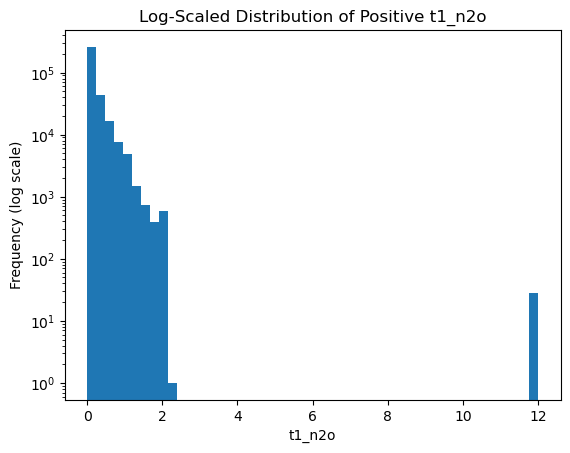

In [25]:
#Plot distribution of positive values for t1_n2o (log scale)

plt.figure()
plt.hist(numeric_features['t1_n2o'][numeric_features['t1_n2o'] > 0], bins=50)
plt.yscale("log")
plt.xlabel("t1_n2o")
plt.ylabel("Frequency (log scale)")
plt.title("Log-Scaled Distribution of Positive t1_n2o")
plt.show()

Note: for all features except for n2o, the percentage of negative values represent < 1% of the total observations. For n2o, the percentage of negative values is significantly higher at ~ 20.6%.  

In terms of the distribution of the negative values, for all concentration based variables, the negative values are distributed near zero. 

For inflow, the negative outliers are much larger in magnitude, with the minimum at -5572.5 m3. 

In [26]:
# Review distribution of negative inflow values 

#total number of negative inflow values
total_negative_inflow = (numeric_features['inflow'] < 0).sum()
print(f"Total number of negative inflow values: {total_negative_inflow}")

# Distribution of negative inflow values
negative_inflow_distribution = numeric_features[numeric_features['inflow'] < 0]['inflow'].describe()
print("Distribution of negative inflow values:")
print(negative_inflow_distribution)

Total number of negative inflow values: 198
Distribution of negative inflow values:
count     198.000000
mean     -833.994650
std      1002.812838
min     -5572.451660
25%     -1042.098358
50%      -358.183044
75%      -172.281803
max       -12.849655
Name: inflow, dtype: float64


In [27]:
# Check if negative values occur in isolated instances or in consecutive sequences

#Define mask for negative inflow values 
neg_mask = numeric_features["inflow"] < 0

# Identify consecutive sequences of negative inflow values
negative_sequences = neg_mask.groupby(neg_mask.ne(neg_mask.shift()).cumsum()).sum()

# Filter out instances of negative inflow 
negative_sequences = negative_sequences[negative_sequences > 0]

negative_sequences.describe()

count    189.000000
mean       1.047619
std        0.213524
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: inflow, dtype: float64

**Interpretation:** the count of isolated sequences of negative inflow values (1 or more consecutive negative values) is 189 which indicates that most of the negative observations are isolated instances (total number of negative inflow values is 198), likely caused by sensor issues, etc. 

The longest consecutive sequence of negative values is 2. Therefore we will use interpolation to estimate the missing inflow values using the length of the interval between the observations. 

##### Apply transformations to negative outliers

In [28]:
#Apply linear shift to negative concentration values 
cols_linear = ['t1_n2o','t1_nh4', 't1_no3', 't1_do']
min_values = df_t1[cols_linear].min() 
shifts = (-min_values).clip(lower=0)

#Apply constant shift to each column
df_t1[cols_linear] = df_t1[cols_linear].add(shifts)

In [29]:
#Verify minima 
df_t1[cols_linear].min()

t1_n2o    0.0
t1_nh4    0.0
t1_no3    0.0
t1_do     0.0
dtype: float64

In [30]:
#For inflow, interpolate values since negative outliers are isolated cases 

#Ensure that df is in chronological order
df_t1 = df_t1.sort_index()

#Identify negative inflow values and set to NaN
neg_mask_inflow = df_t1['inflow'] < 0 
df_t1.loc[neg_mask_inflow,'inflow'] = np.nan

#interpolate using length of interval between observations
df_t1['inflow'] = df_t1['inflow'].interpolate(method='time',limit_area='inside')

In [31]:

#Check for any remaining negative values 
remaining_negatives = (df_t1['inflow'] < 0).sum()
print(f"Number of remaining negative inflow values after interpolation: {remaining_negatives}")

#Check NaN values
nan_counts = df_t1['inflow'].isna().sum()
print(f"Number of NaN values in inflow after interpolation: {nan_counts}")

Number of remaining negative inflow values after interpolation: 0
Number of NaN values in inflow after interpolation: 112043


##### Check NaN values for Inflow 

In [32]:
#select inflow column and check for leading and trailing NaNs
inflow_s = df_t1["inflow"]
print("Leading NaNs:", inflow_s.isna().cumprod().sum())
print("Trailing NaNs:", inflow_s.isna()[::-1].cumprod().sum())

Leading NaNs: 112043
Trailing NaNs: 0


In [33]:
#Identify consecutive NaN gaps in inflow and compute their lengths
inflow_na = inflow_s.isna()
gap_id = inflow_na.ne(inflow_na.shift()).cumsum()
gap_lengths = inflow_na.groupby(gap_id).sum()
missing_gaps = gap_lengths[gap_lengths > 0]

missing_gaps.describe()


count         1.0
mean     112043.0
std           NaN
min      112043.0
25%      112043.0
50%      112043.0
75%      112043.0
max      112043.0
Name: inflow, dtype: float64

In [34]:
#Check when NaN values occur
first_valid = inflow_s.first_valid_index()

print("NaNs occur from", inflow_s.index.min(), "to", inflow_s.loc[:first_valid].index[inflow_s.loc[:first_valid].isna()].max())
print("Any NaNs after first valid?", inflow_s.loc[first_valid:].isna().any())


NaNs occur from 2022-06-11 22:01:00+00:00 to 2022-09-12 10:13:00+00:00
Any NaNs after first valid? False


**Interpretation:**

NaN values for inflow occur in one continuous missing block of 112,043 rows from 2022-06-11 22:01:00+00:00 to 2022-09-12 10:13:00+00:00 in the beginning of the dataset. 

To be handled in the next step when eliminating gaps in the dataset. 

### II. Exploratory Data Analysis 

#### Global EDA (raw data - before resampling)

##### Global Timeseries Overview 

In [35]:
#Check descriptive statistics after treating negative values 
df_t1[cols_num].describe().round(2) 

,inflow,total_airflow,t1_airflow,t1_n2o,t1_nh4,t1_no3,t1_do,t1_ss,t1_temp,t1_po4
count,686423.00,520534.00,470173.00,505759.00,520548.00,519651.00,510296.00,520583.00,505210.00,518090.00
mean,3100.25,17134.54,2188.87,0.13,2.31,3.12,0.65,2.55,15.66,1.12
std,2327.95,7339.69,2133.81,0.24,2.21,2.78,0.61,0.86,3.38,0.96
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.49,0.00
25%,2095.49,11566.58,0.00,0.01,0.95,1.52,0.19,2.14,12.62,0.51
50%,2310.76,16801.08,2166.19,0.04,1.87,2.51,0.37,2.55,15.64,0.89
75%,4322.92,21809.25,4020.05,0.14,3.03,4.07,1.03,2.96,18.91,1.44
max,17192.57,43356.56,12973.05,12.02,20.01,53.00,10.89,35.09,27.13,16.56


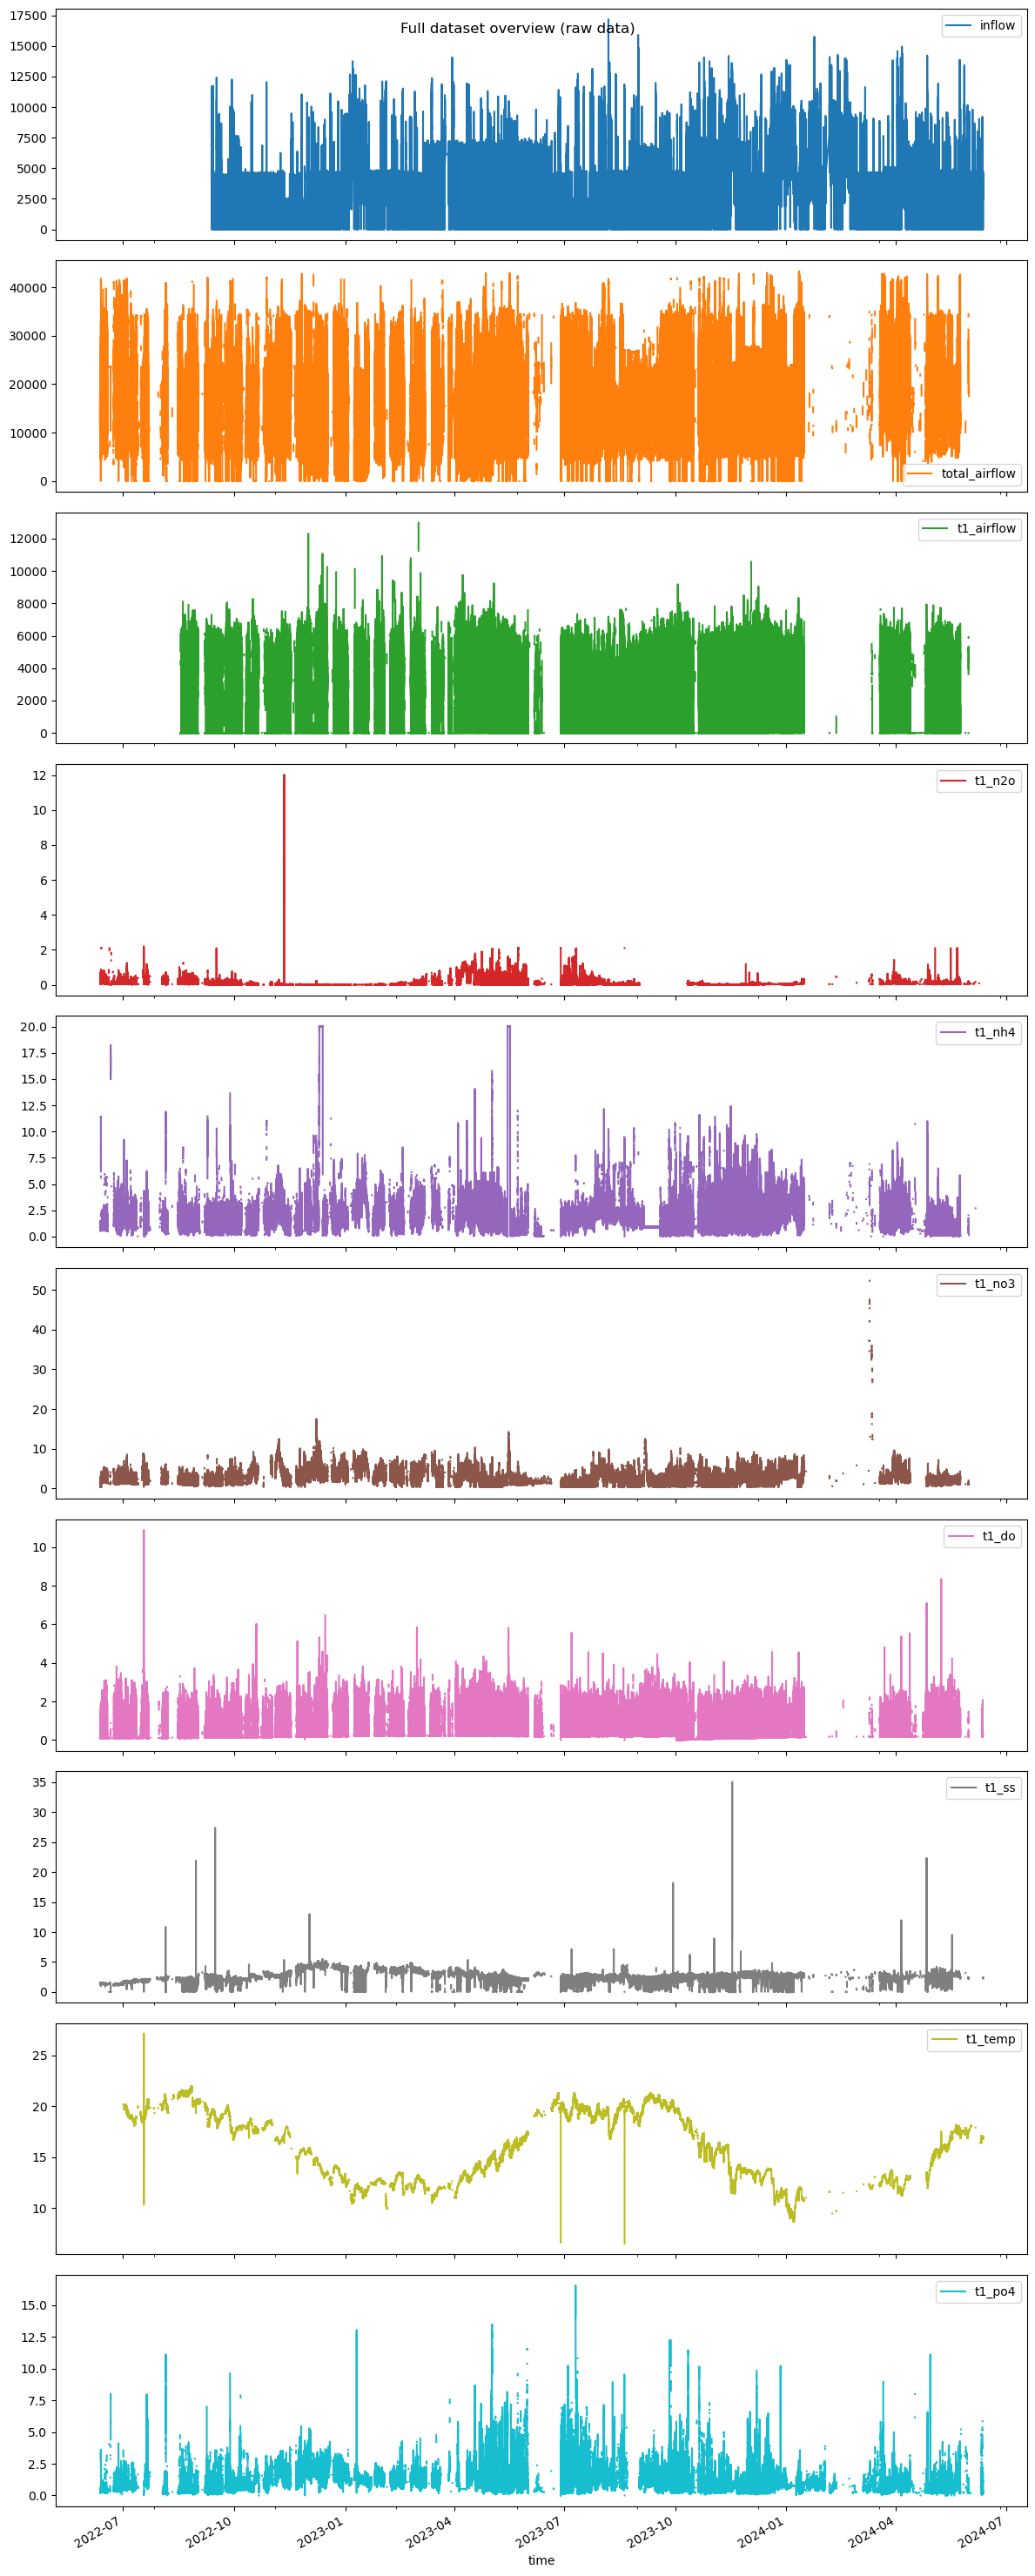

In [36]:
#Global overview of numeric variables after treating negative values
plot_df = df_t1[cols_num].copy() 
plot_df.plot(subplots=True, figsize=(12,30), title="Full dataset overview (raw data)") 
plt.tight_layout()
plt.show()

#### Initial view of outliers

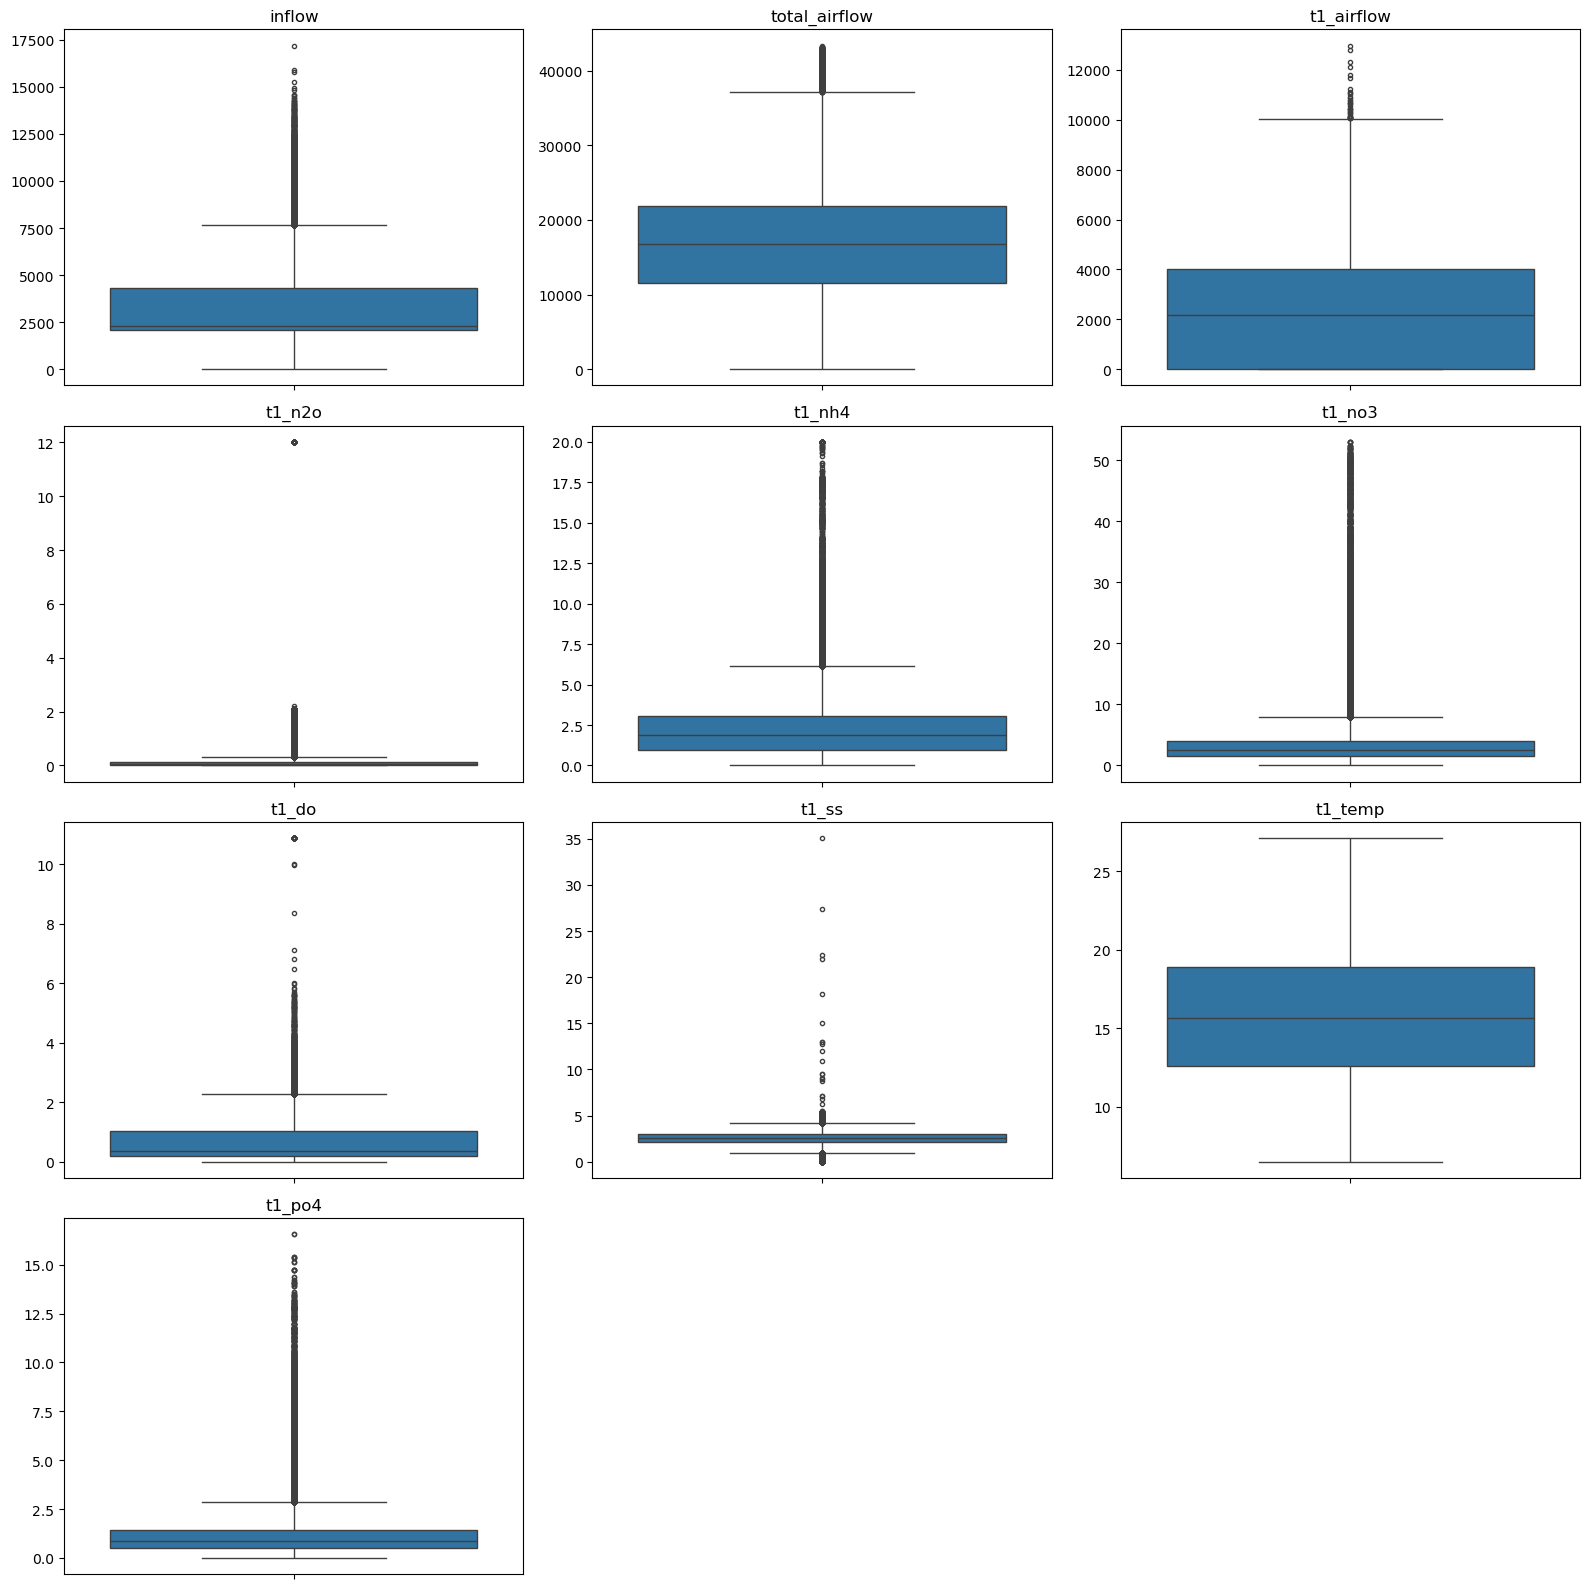

In [37]:
#Boxplots to check for outliers after treating negative values

n_cols = 3
n_rows = math.ceil(len(cols_num) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.boxplot(y=df_t1[col], ax=axes[i],
            flierprops=dict(marker='o', markersize=3))
    axes[i].set_title(col)
    axes[i].set_ylabel("")
    
# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Aligning Timestamps, Resampling Data & Handling Missing Values 


Two approaches: 
1. Aligning timestamps by flooring observations to the nearest minute 
2. Resampling directly without flooring observations (2 min for EDA, 10 min for modelling)

In [38]:
#Define features used to select rows with missing values in key variables
features = ['t1_n2o', 't1_do', 't1_airflow', 't1_nh4', 't1_no3', 't1_temp']

##### Option 1. Shift timestamps, then resample to 10 min frequency

In [39]:
#Create duplicate dataframe for aligning timestamps 
df_aligned = df_t1.copy() 

#Ensure chronological order 
df_aligned = df_aligned.sort_index()

print(f"Original number of rows:", {len(df_t1)})


Original number of rows: {798466}


In [40]:
#Store original timezone 
orig_tz = df_aligned.index.tz
df_aligned.index = df_aligned.index.tz_localize(None)

#Floor to the nearest minute (round down)
df_aligned.index = df_aligned.index.floor('1T')

#Create copy of timestamp array 
new_times = df_aligned.index.values.copy()

#Save minute portion
minutes = df_aligned.index.minute

#Shift even minutes back by 1 minute
even_mask = (minutes % 2 == 0)
new_times[even_mask] -= np.timedelta64(1, 'm')

#Replace df_aligned index with adjusted timestamps
df_aligned.index = pd.DatetimeIndex(new_times)

#Remove duplicates by grouping rows by timestamp
#Only the values in the first rows are kept - can drop data?
df_aligned = df_aligned.groupby(level=0).first()

#Filter out even minutes
df_aligned = df_aligned[df_aligned.index.minute % 2 != 0]

#Reapply original timezone 
if orig_tz is not None:
    df_aligned.index = df_aligned.index.tz_localize(orig_tz)

#Sort chronologically 
df_aligned = df_aligned.sort_index()

#Check shape of new df and verify that even timestamps have been removed
print(f"--- Completed ---")
print(f"Original number of rows: {len(df_t1)}")
print(f"Aligned total rows: {len(df_aligned)}")
print(f"Even timestamp exists: {(df_aligned.index.minute % 2 == 0).any()}")

--- Completed ---
Original number of rows: 798466
Aligned total rows: 520868
Even timestamp exists: False


In [41]:
#Check data integrity by comparing the number of NaN and zero values in original and aligned dataframes for value columns

def check_data_integrity(original_df, processed_df):
    
    stats = []
    
    numeric_cols = original_df.select_dtypes(include='number').columns
    
    for col in numeric_cols:
        
        orig_series = original_df[col]
        processed_series = processed_df[col] if col in processed_df.columns else None
        
        orig_count = len(orig_series)
        processed_count = len(processed_series) if processed_series is not None else np.nan

        orig_nan = orig_series.isna().sum()
        processed_nan = processed_series.isna().sum() if processed_series is not None else np.nan

        stats.append({
            'Feature': col,
            
            # ---- NaN counts ----
            'Original_NaN': orig_nan,
            'Processed_NaN': processed_nan,
            
            # ---- % NaN ----
            'Original_%_NaN': (orig_nan / orig_count) * 100,
            'Processed_%_NaN': (processed_nan / processed_count) * 100 if processed_series is not None else np.nan,
            
            # ---- Zero counts ----
            'Original_Zeros': (orig_series == 0).sum(),
            'Processed_Zeros': (processed_series == 0).sum() if processed_series is not None else np.nan,
            
            # ---- Mean ----
            'Original_Mean': orig_series.mean(),
            'Processed_Mean': processed_series.mean() if processed_series is not None else np.nan,
            'Mean_Diff': (processed_series.mean() - orig_series.mean()) if processed_series is not None else np.nan,
            
            # ---- Standard Deviation ----
            'Original_Std': orig_series.std(),
            'Processed_Std': processed_series.std() if processed_series is not None else np.nan,
            'Std_Diff': (processed_series.std() - orig_series.std()) if processed_series is not None else np.nan,
            
            # ---- Sum ----
            'Original_Sum': orig_series.sum(),
            'Processed_Sum': processed_series.sum() if processed_series is not None else np.nan,
            'Sum_Diff': (processed_series.sum() - orig_series.sum()) if processed_series is not None else np.nan,
            'Sum_%_Diff': ((processed_series.sum() - orig_series.sum()) 
               / orig_series.sum()) * 100
               if processed_series is not None else np.nan,
            
            # ---- Min / Max ----
            'Original_Min': orig_series.min(),
            'Processed_Min': processed_series.min() if processed_series is not None else np.nan,
            'Original_Max': orig_series.max(),
            'Processed_Max': processed_series.max() if processed_series is not None else np.nan
        })
        
    return pd.DataFrame(stats)

In [42]:
#Check general statistics for original and aligned dataframes
comparison_aligned = check_data_integrity(df_t1[features], df_aligned[features])
comparison_aligned.head().round(3) 

,Feature,Original_NaN,Processed_NaN,Original_%_NaN,Processed_%_NaN,Original_Zeros,Processed_Zeros,Original_Mean,Processed_Mean,Mean_Diff,Original_Std,Processed_Std,Std_Diff,Original_Sum,Processed_Sum,Sum_Diff,Sum_%_Diff,Original_Min,Processed_Min,Original_Max,Processed_Max
0,t1_n2o,292707,17087,36.659,3.280,78226,78198,0.130,0.130,-0.000,0.244,0.243,-0.001,6.579651e+04,6.533627e+04,-460.238,-0.699,0.0,0.0,12.024,12.024
1,t1_do,288170,14298,36.090,2.745,1,0,0.655,0.655,-0.000,0.612,0.612,-0.000,3.341893e+05,3.315871e+05,-2602.172,-0.779,0.0,0.0,10.887,10.887
2,t1_airflow,328293,50841,41.115,9.761,193767,193707,2188.871,2188.793,-0.078,2133.812,2133.760,-0.052,1.029148e+09,1.028792e+09,-356325.924,-0.035,0.0,0.0,12973.047,12973.047
3,t1_nh4,277918,2740,34.806,0.526,2,2,2.312,2.314,0.002,2.210,2.208,-0.002,1.203504e+06,1.199070e+06,-4433.424,-0.368,0.0,0.0,20.012,20.012
4,t1_no3,278815,4041,34.919,0.776,1,1,3.116,3.120,0.004,2.778,2.781,0.003,1.619344e+06,1.612708e+06,-6635.926,-0.410,0.0,0.0,52.997,52.997


**Notes on results:** 

- Significant decrease in % of NaN values (% of values in a given column that are NaN)
- Zero values: approximately the same, no significant change 
- Mean: no significant change in mean values 
- Standard deviation: no significant change
- Sum: processed data set has lower sum than the original, which indicates some values were removed due to aggregation (only first duplicate kept) - howedver, the changes are relatively small (approx -0.8 to -0.01%). 
- Min/Max - no change 

##### Statistical distribution check & plots

**Density Plots (aligned vs. original)**

<Figure size 1200x800 with 0 Axes>

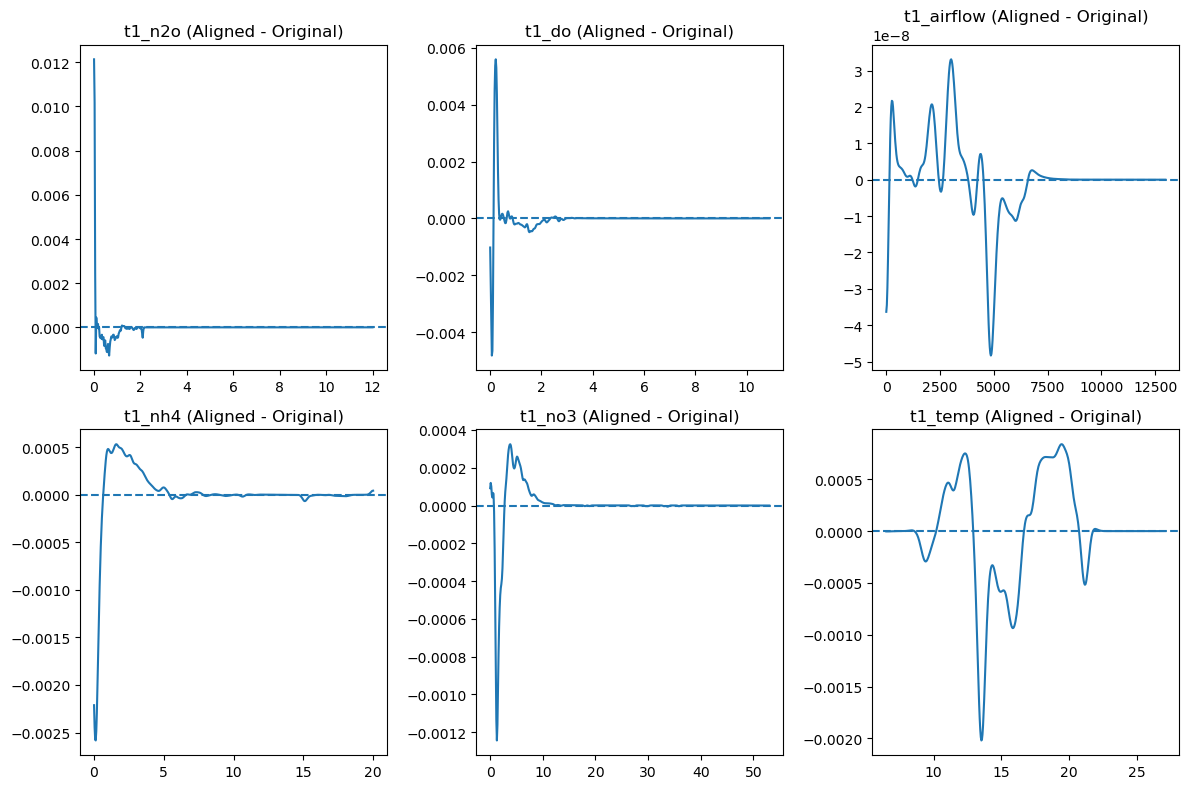

In [43]:
#Check data distribution (original vs. aligned)
plt.figure(figsize=(12,8))

#Plot KDEs for each six key features in original and aligned dataframes
plt.figure(figsize=(12,8))

for i, col in enumerate(features):
    plt.subplot(2,3,i+1)

    # Drop NaNs
    orig = df_t1[col].dropna()
    aligned = df_aligned[col].dropna()

    # Create common grid
    x = np.linspace(
        min(orig.min(), aligned.min()),
        max(orig.max(), aligned.max()),
        500
    )

    kde_orig = gaussian_kde(orig)
    kde_aligned = gaussian_kde(aligned)

    diff = kde_aligned(x) - kde_orig(x)

    plt.plot(x, diff)
    plt.axhline(0, linestyle='--')
    plt.title(f"{col} (Aligned - Original)")

plt.tight_layout()
plt.show()

Density plots mapping KDE(aligned) - KDE(original) using Gaussian KDE 
- Curves are close to zero, indicating that differences between the two distributions is very small (magnitudes of 10⁻³ to 10⁻⁸)

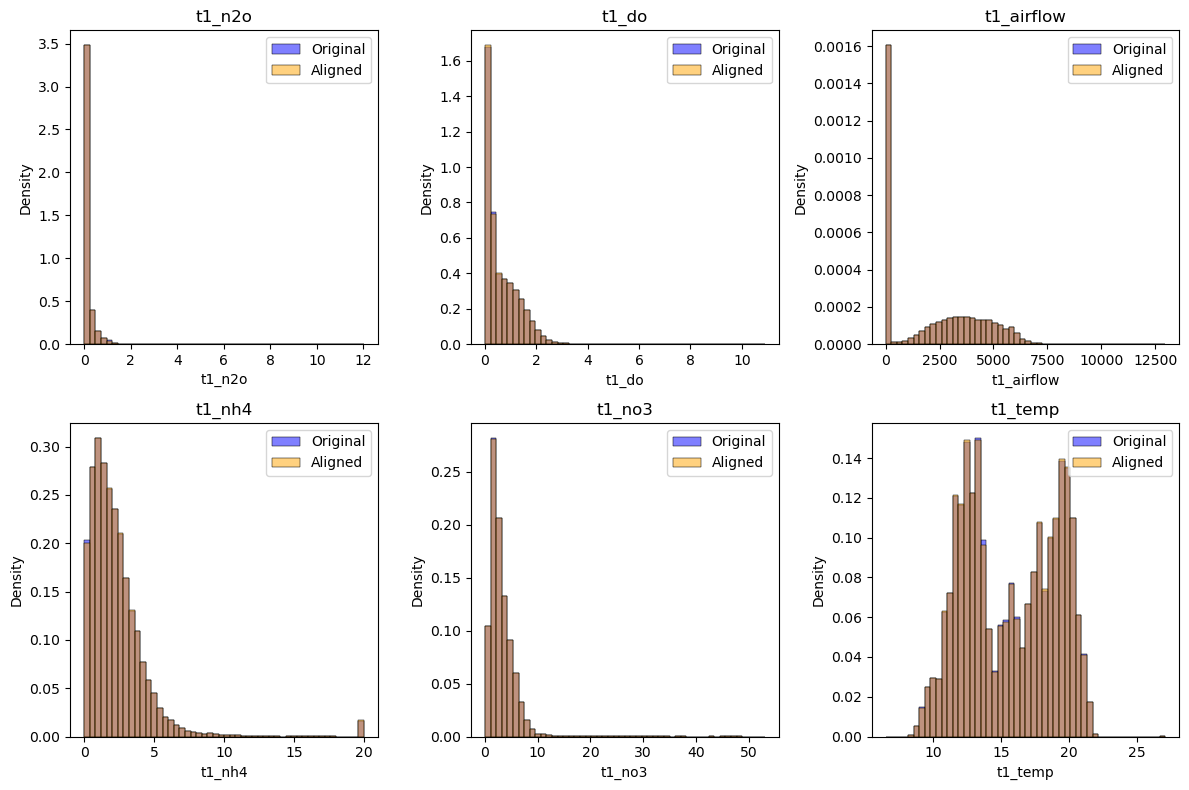

In [44]:
#Plot histograms for original and aligned dataframes to visually compare distributions
plt.figure(figsize=(12,8))

for i, col in enumerate(features):
    plt.subplot(2,3,i+1)

    sns.histplot(df_t1[col], bins=50, stat="density",
                 color="blue", alpha=0.5, label="Original")

    sns.histplot(df_aligned[col], bins=50, stat="density",
                 color="orange", alpha=0.5, label="Aligned")

    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

**Notes:** 
- The original and aligned bars alsomt perfectly overlap, indicating that shifting the data did not impact the distribution of the data 
- No new peaks or visible / significant shifts in central tendency 
- No loss of extreme values (max. stays the same for both sets)

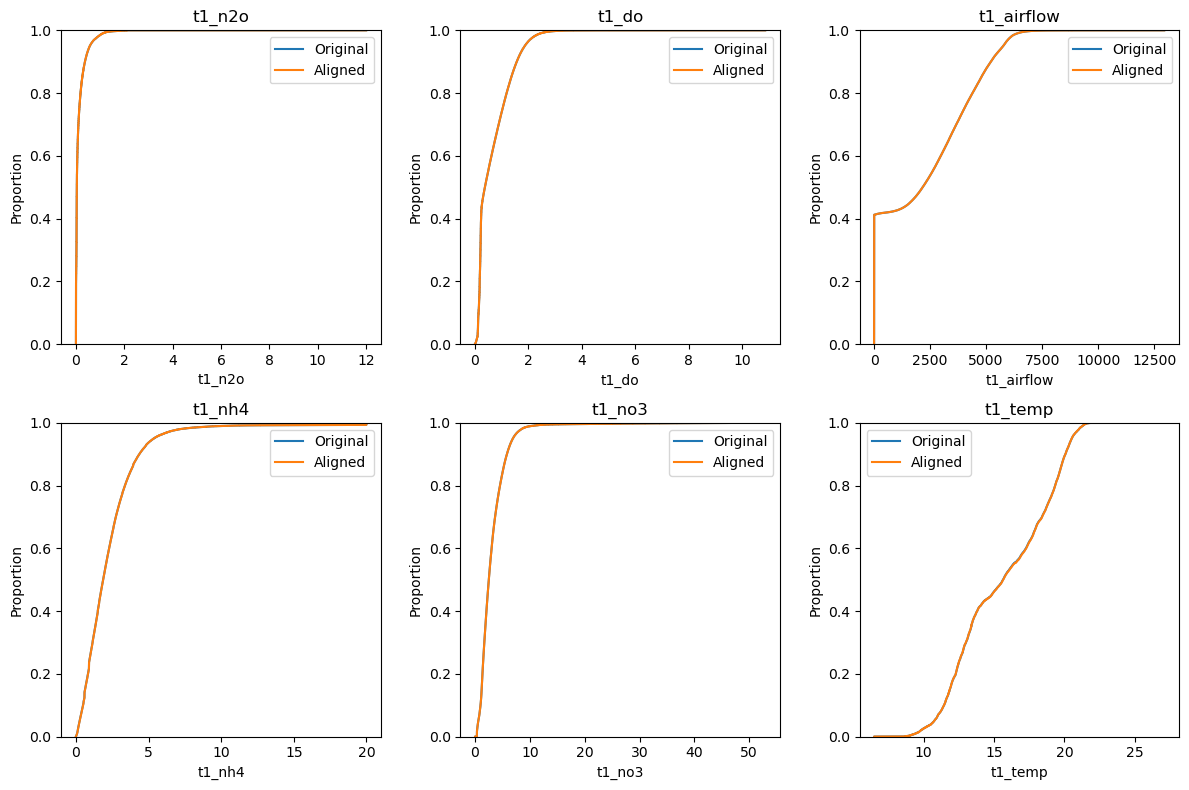

In [45]:
plt.figure(figsize=(12,8))

#Plot ECDFs for original and aligned dataframes to visually compare distributions
for i, col in enumerate(features):
    plt.subplot(2,3,i+1)

    sns.ecdfplot(df_t1[col], label="Original")
    sns.ecdfplot(df_aligned[col], label="Aligned")

    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

**Notes:**
- As with with histograms and difference in KDE density curves, the ECDF curves almost perfectly overlap 
- No divergence at the tails or horizontal shift 

**Interpretation for individual variables:**

- t1_no2: rapid increase near zero, strong right-skewed distribution, few extreme values
- t1_do: moderate steepness, reflects controlled aeration system 
- t1_airflow: sharp jump at 0 (significant fraction of time airflow is ~0), mid-range S-curve (when aeration is ON?)
- t1_nh4: steep rise at low values, right-skew, most NH4 concentrations are low with some high spikes (depends on rate of ammonia removal?)
- t1_no3: steep initial rise as with NO2 and NH4 and right skew reflecting peaks in nitrate accumulation, mostly low concentrations
- t1_temp - s-curve, no significant skew, suggests distinct temperature regimes (day vs. night?, seasonal?) 

Strong right skew of data -> data transformations for modeling

In [46]:
#Finally, compute KS test statistic and p-value for each feature to quantitatively compare distributions of original and aligned dataframes
for col in features:
    stat, p = ks_2samp(
        df_t1[col].dropna(),
        df_aligned[col].dropna()
    )
    print(f"{col}: KS p-value = {p:.4f}")

t1_n2o: KS p-value = 1.0000
t1_do: KS p-value = 0.9971
t1_airflow: KS p-value = 1.0000
t1_nh4: KS p-value = 0.7805
t1_no3: KS p-value = 0.9235
t1_temp: KS p-value = 0.2831


All KS p-values are > 0.05, and therefore we can reject the null hypothesis that shifting the data changes the distribution of any of the variabes. 

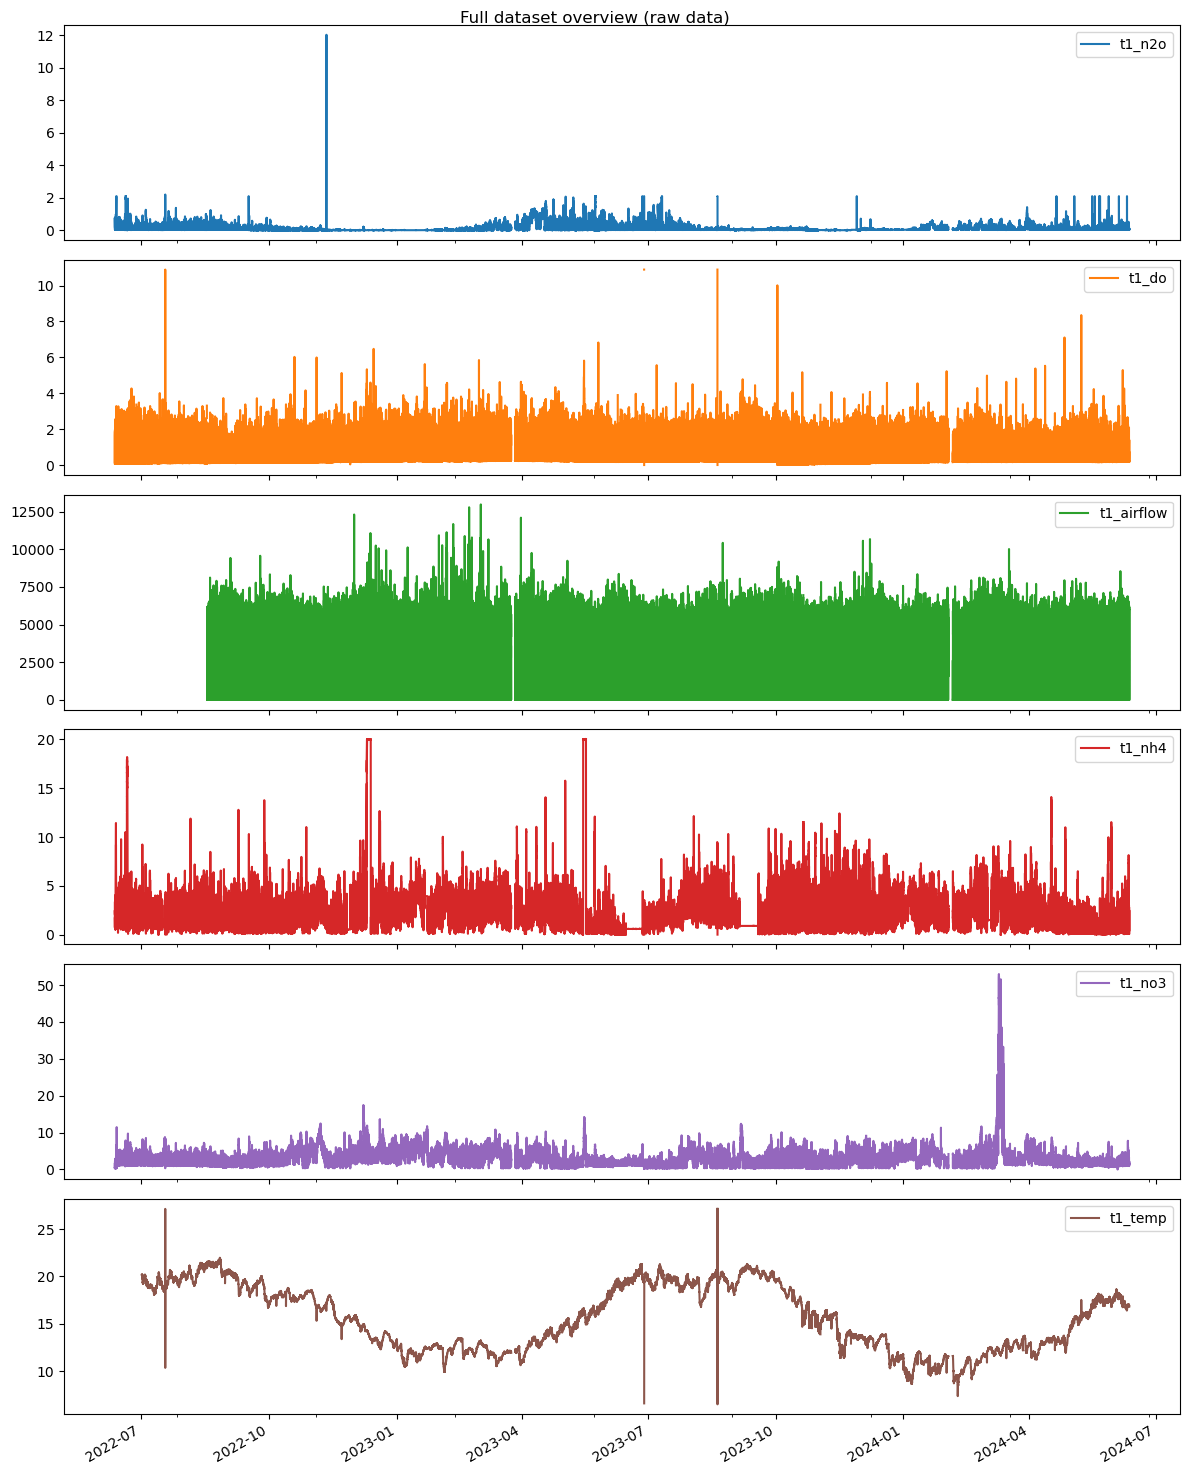

In [47]:
plot_df = df_aligned[features].copy()
plot_df.plot(subplots=True, figsize=(12,15), title="Full dataset overview (raw data)") 
plt.tight_layout(); plt.show()

#### 2. Resample (2 min, 10 min)

##### Check distribution of gaps in data 

##### Handle Outliers

Only a single outlier was removed for N2O, which is a clear outlier / extreme value not related to operational variability. 

**Note:** therewere 27 extreme values which were all equal to 12.02 occurring in a single cluster, indicating that this is a likely sensor malfunction / logging issue (the new max after removing the extremes is 2.2).

(Potentially add literature reference to justify keeping extremes - importance for real time monitoring + training model that can generalize to periods of high spikes)

In [48]:
#Remove single N2O value 
max_idx = df_t1["t1_n2o"].idxmax()
print(f"Max t1_n2o value: {df_t1.loc[max_idx, 't1_n2o']} at timestamp {max_idx}")

#remove single outlier value 
df_t1.loc[max_idx, "t1_n2o"] = np.nan

Max t1_n2o value: 12.023726852610707 at timestamp 2022-11-11 08:36:00+00:00


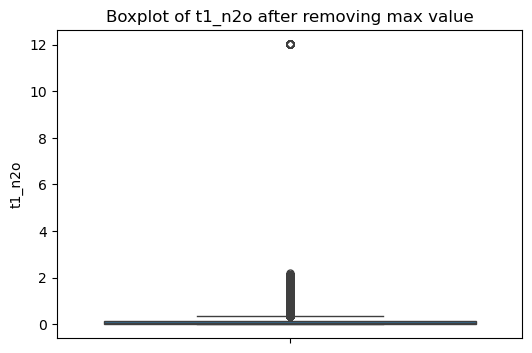

In [49]:
#plot boxplot for t1_n2o to check for outliers after removing max value
plt.figure(figsize=(6,4))
sns.boxplot(y=df_t1['t1_n2o'], flierprops=dict(marker='o', markersize=5))
plt.title("Boxplot of t1_n2o after removing max value")
plt.ylabel("t1_n2o")
plt.show()

In [50]:
df_t1[df_t1["t1_n2o"] == df_t1["t1_n2o"].max()][["t1_n2o"]]

,t1_n2o
time,
2022-11-11 08:38:00+00:00,12.023727
2022-11-11 08:40:00+00:00,12.023727
2022-11-11 08:42:00+00:00,12.023727
2022-11-11 08:44:00+00:00,12.023727
2022-11-11 08:46:00+00:00,12.023727
2022-11-11 08:48:00+00:00,12.023727
2022-11-11 08:50:00+00:00,12.023727
2022-11-11 08:52:00+00:00,12.023727
2022-11-11 08:54:00+00:00,12.023727


In [51]:
extreme_count = (df_t1["t1_n2o"] > 5).sum()

print("Number of extreme N2O values (>5):", extreme_count)

extreme_pct = (df_t1["t1_n2o"] > 5).mean() * 100

print(f"Percentage of extreme N2O values: {extreme_pct:.4f}%")

Number of extreme N2O values (>5): 27
Percentage of extreme N2O values: 0.0034%


In [52]:
df_t1[df_t1["t1_n2o"] > 5]["t1_n2o"].describe().round(2)

count    27.00
mean     12.02
std       0.00
min      12.02
25%      12.02
50%      12.02
75%      12.02
max      12.02
Name: t1_n2o, dtype: float64

In [53]:
df_t1[df_t1["t1_n2o"] > 5].index

DatetimeIndex(['2022-11-11 08:38:00+00:00', '2022-11-11 08:40:00+00:00',
               '2022-11-11 08:42:00+00:00', '2022-11-11 08:44:00+00:00',
               '2022-11-11 08:46:00+00:00', '2022-11-11 08:48:00+00:00',
               '2022-11-11 08:50:00+00:00', '2022-11-11 08:52:00+00:00',
               '2022-11-11 08:54:00+00:00', '2022-11-11 08:56:00+00:00',
               '2022-11-11 08:58:00+00:00', '2022-11-11 09:00:00+00:00',
               '2022-11-11 09:02:00+00:00', '2022-11-11 09:04:00+00:00',
               '2022-11-11 09:06:00+00:00', '2022-11-11 09:38:00+00:00',
               '2022-11-11 09:40:00+00:00', '2022-11-11 09:42:00+00:00',
               '2022-11-11 09:44:00+00:00', '2022-11-11 09:46:00+00:00',
               '2022-11-11 09:48:00+00:00', '2022-11-11 09:50:00+00:00',
               '2022-11-11 09:52:00+00:00', '2022-11-11 09:54:00+00:00',
               '2022-11-11 09:56:00+00:00', '2022-11-11 09:58:00+00:00',
               '2022-11-11 10:00:00+00:00'],
      

In [54]:
df_t1.loc[df_t1["t1_n2o"] > 5, "t1_n2o"] = np.nan
print("Remaining extreme values:", (df_t1["t1_n2o"] > 5).sum())
print("New max value:", df_t1["t1_n2o"].max())

Remaining extreme values: 0
New max value: 2.1938656885176897


##### Resampling (2min & 10min)

- For numerical variables: use mean

- For categorical / discrete states: use mode to identify dominant phase during the window (plot to see if this significantly changes phase distribution)
- Storm mode - use max to preserve storm events (occurrence within the chosen period)
- Quality flags - mode to select most frequent quality window 

In [55]:
#Resample original dataframe df_t1 (final resampling frequency will be 10 min)

#sort to ensure chronological order
df_t1 = df_t1.sort_index()

#Define column groups for resampling

continuous_cols = [
    'total_airflow', 't1_valve_pct', 't1_n2o', 't1_nh4', 't1_no3', 't1_do', 't1_do_sp', 't1_airflow', 't1_ss',
    't1_temp', 't1_po4', 'inflow'
]

phase_cols = ['t1_phase', 'phasecode', 'inlet_tank', 'outlet_tank']

binary_cols = ['storm_mode']

quality_cols = [col for col in df_t1.columns if col.endswith('_q')]

In [56]:
#Define resampling function

def resample_mixed(df, freq):

    df = df.sort_index()

    # Continuous → mean
    df_cont = df[continuous_cols].resample(freq).mean()

    # Phase/state → mode
    df_phase = (
        df[phase_cols]
        .resample(freq)
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )

    # Binary → max
    df_binary = df[binary_cols].resample(freq).max()

    # Quality flags → mode (safe default)
    df_quality = (
        df[quality_cols]
        .resample(freq)
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )

    # Combine
    df_resampled = pd.concat(
        [df_cont, df_phase, df_binary, df_quality],
        axis=1
    )

    return df_resampled

In [57]:
#Resample to 2 min and 10 min frequencies
df_2T = resample_mixed(df_t1, "2T")
df_10T = resample_mixed(df_t1, "10T")

In [58]:
#Check shapes of resampled dataframes
print(f"Original df shape: {df_t1.shape}")
print(f"2 min resampled df shape: {df_2T.shape}")
print(f"10 min resampled df shape: {df_10T.shape}") 

Original df shape: (798466, 34)
2 min resampled df shape: (526320, 34)
10 min resampled df shape: (105264, 34)


In [59]:
import os
print(os.getcwd())

e:\2025-2026\CIVE70088\Coursework


#### Quick overview of distribution after resampling 

TO DO: 
- analysis of NaN gaps (rows with key features missing) - see longest segments of continious data
- extreme value analysis (monthly basis to capture phase specific trends? or clustering to identify segments with high emissions?)

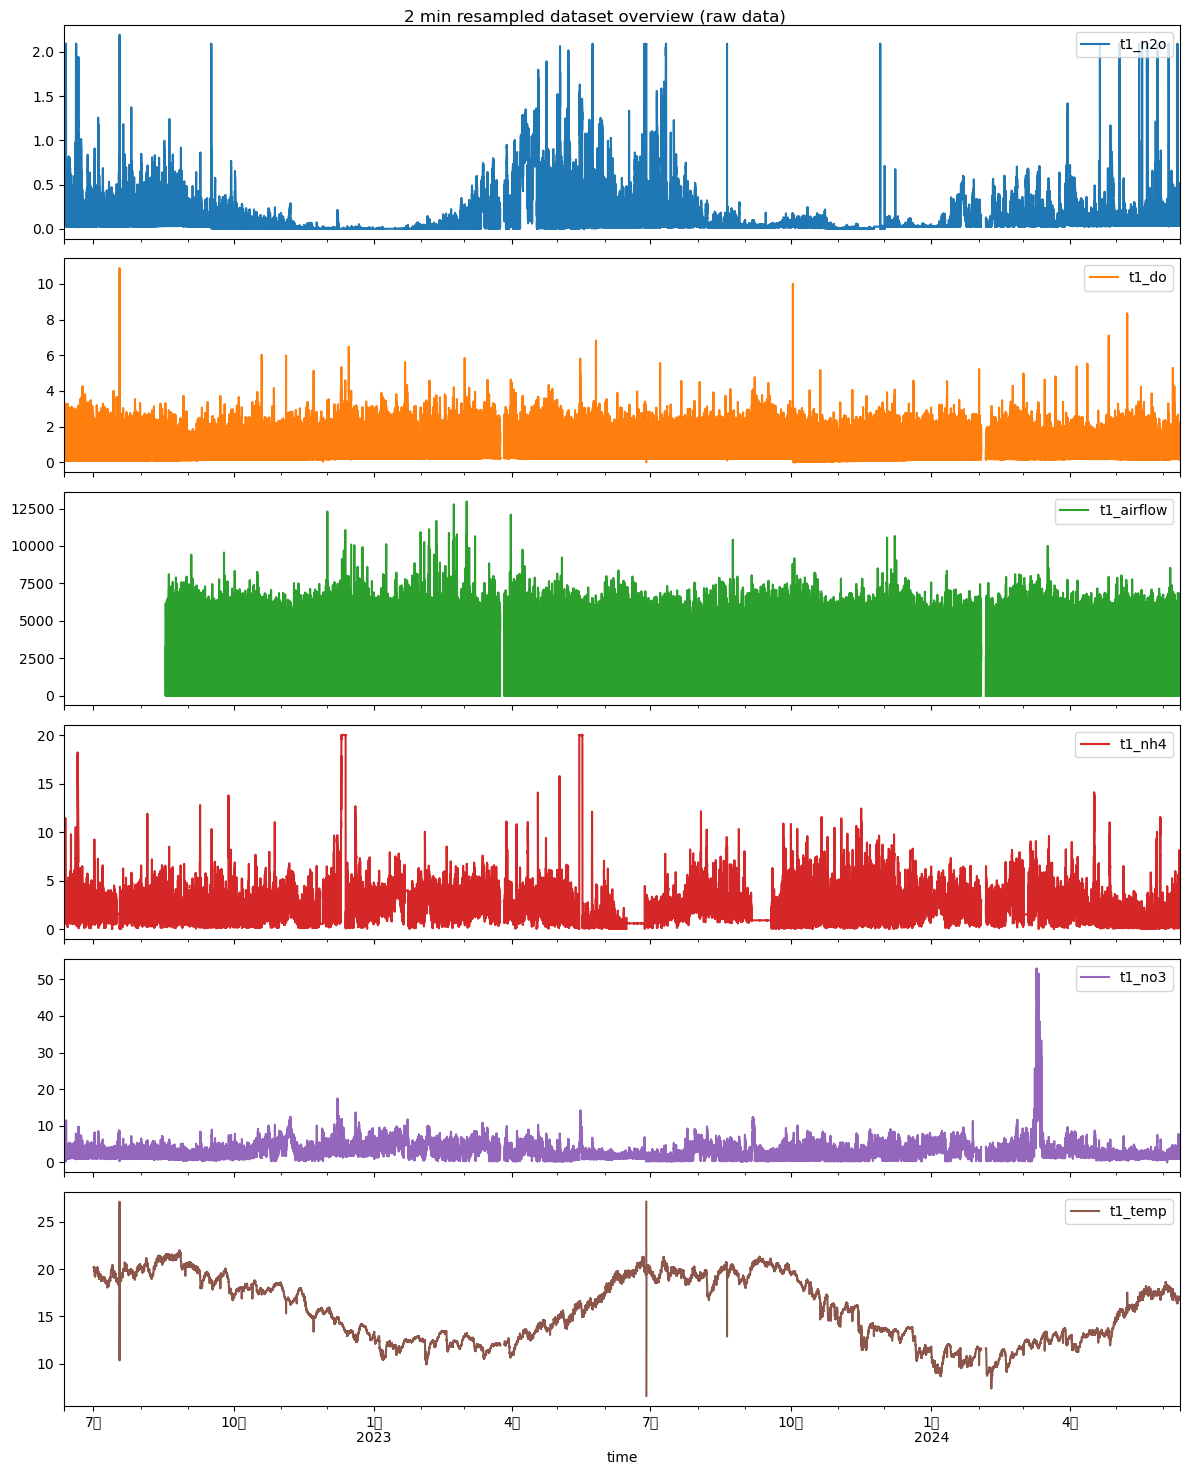

In [61]:
plot_df_2T = df_2T[features].copy()
plot_df_2T.plot(subplots=True, figsize=(12,15), title="2 min resampled dataset overview (raw data)") 
plt.tight_layout(); plt.show()

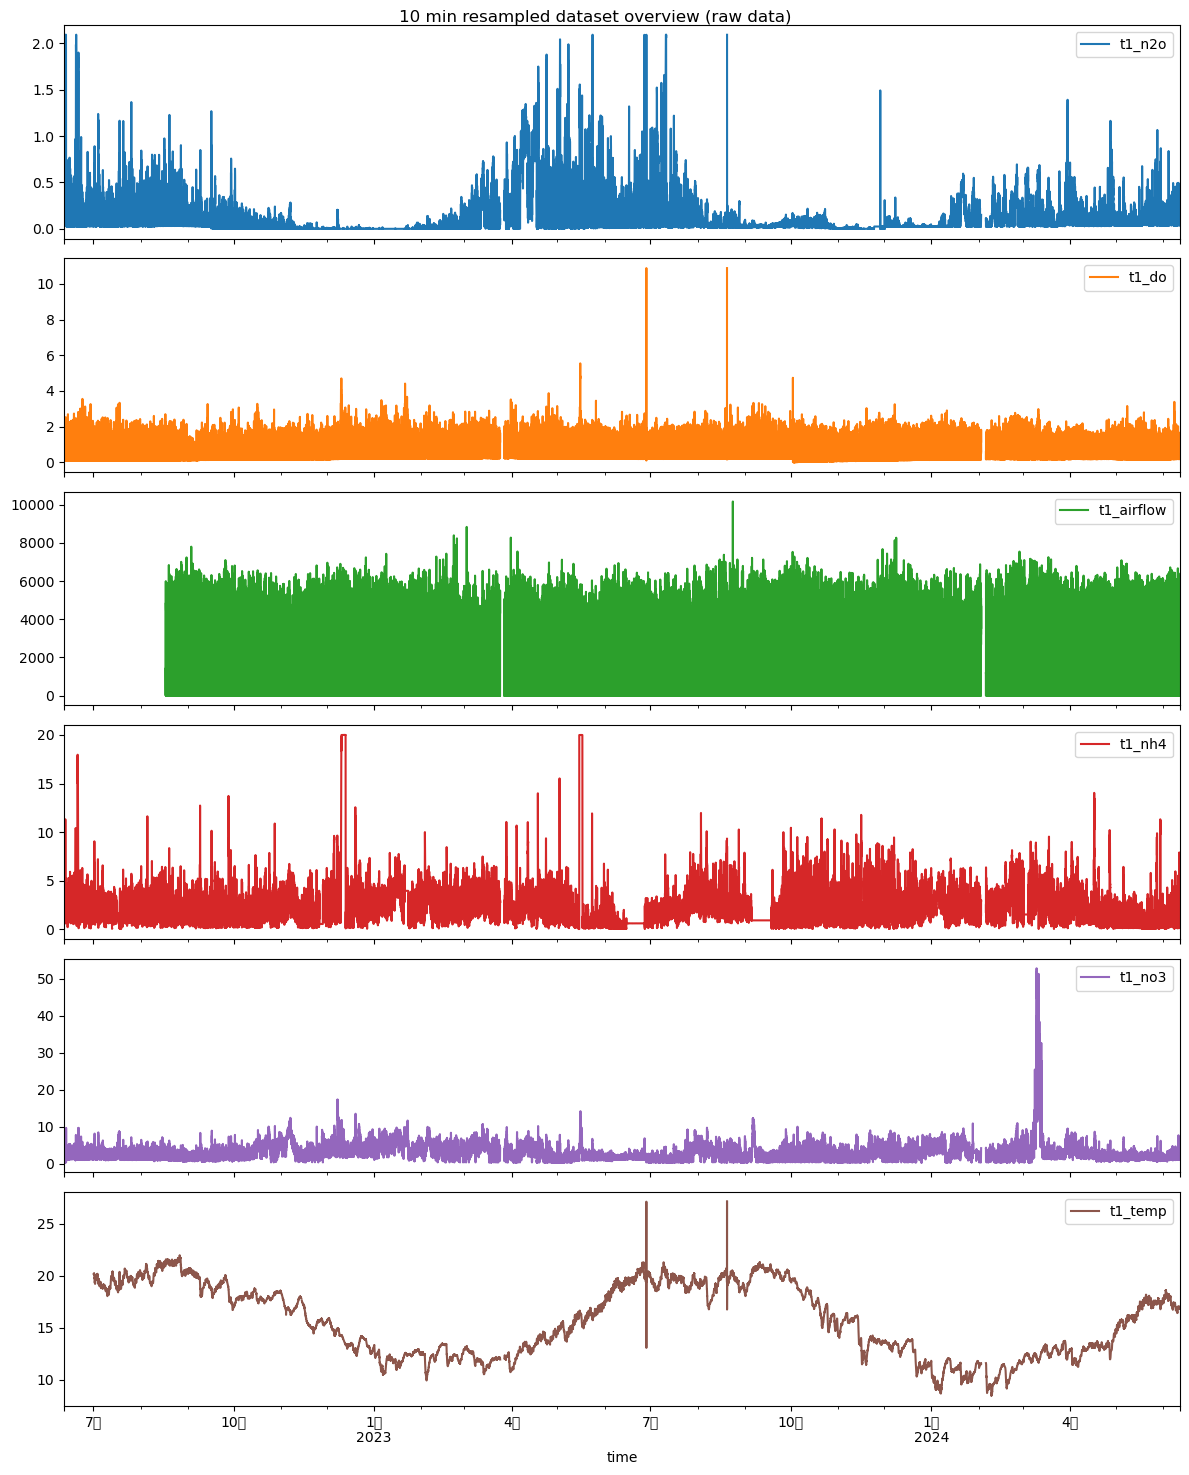

In [62]:
plot_df_10T = df_10T[features].copy()
plot_df_10T.plot(subplots=True, figsize=(12,15), title="10 min resampled dataset overview (raw data)") 
plt.tight_layout(); plt.show()

### Local EDA (to be completed once groupings confirmed)

##### Handling missing values

An initial threshold of 1 day is applied to drop consecutive periods where data is missing for t1_n2o, t1_do, t1_airflow, t1_nh4, t1_no3, and t1_temp.

In [93]:
df_10T = df_10T.copy() 

#Check for missing values across each variable 
missing_values = df_10T.isnull().sum() 
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
total_airflow       1075
t1_valve_pct        4644
t1_n2o              2805
t1_nh4              1076
t1_no3              1074
t1_do               1482
t1_do_sp           12703
t1_airflow         10699
t1_ss               1074
t1_temp             3894
t1_po4              1126
inflow             14351
t1_phase            1102
phasecode          12703
inlet_tank         12703
outlet_tank        12703
storm_mode         12703
total_airflow_q     1075
t1_valve_pct_q      4644
t1_n2o_q            2801
t1_nh4_q            1076
t1_no3_q            1074
t1_do_q             1482
t1_do_sp_q         12703
t1_phase_q          1102
t1_airflow_q       10699
t1_ss_q             1074
t1_temp_q           3894
phasecode_q        12703
inlet_tank_q       12703
outlet_tank_q      12703
t1_po4_q            1126
inflow_q           14506
storm_mode_q       12703
dtype: int64


In [95]:
#Identify temporal gaps in data (threshold 1-day)
vars_to_check = ['t1_n2o', 't1_do', 't1_airflow', 't1_nh4', 't1_no3', 't1_temp']

#ensure chronological order
df_10T = df_10T.sort_index() 

In [96]:
#Identify rows where all selected variables are present 
valid = df_10T[vars_to_check].notna().all(axis=1)
invalid = ~valid #True if any of the selected variables are missing 

#Identify consecutive periods of missing data for selected variables
block_id = invalid.ne(invalid.shift()).cumsum() #define unique ID for each consecutive block

#extract invalid blocks 
invalid_blocks = df_10T.loc[invalid].groupby(block_id[invalid])

In [97]:
#Check sampling frequency 
time_diffs = df_10T.index.to_series().diff()
print(time_diffs.value_counts().head(10))

time
0 days 00:10:00    105263
Name: count, dtype: int64


**Interpretation:** Sampling interval is now confirmed regular. 

In [104]:
#Define a summary table of the identified gaps in data for selected variables

def summarize_gap(g: pd.DataFrame) -> pd.Series:
    start = g.index.min()
    end = g.index.max()
    return pd.Series({
        "start_time": start,
        "end_time": end,
        "n_rows": len(g),
        "duration": end - start
    })

gap_summary = invalid_blocks.apply(summarize_gap)

print("Summary of data gaps for selected variables:")
print(gap_summary)

Summary of data gaps for selected variables:
                    start_time                  end_time  n_rows  \
1    2022-06-11 22:00:00+00:00 2022-08-17 10:50:00+00:00    9582   
3    2022-08-18 07:00:00+00:00 2022-08-18 08:20:00+00:00       9   
5    2022-08-20 07:00:00+00:00 2022-08-20 07:10:00+00:00       2   
7    2022-08-20 08:30:00+00:00 2022-08-20 08:30:00+00:00       1   
9    2022-08-28 09:20:00+00:00 2022-08-28 09:20:00+00:00       1   
...                        ...                       ...     ...   
1791 2024-02-02 15:20:00+00:00 2024-02-05 18:40:00+00:00     453   
1793 2024-04-09 06:20:00+00:00 2024-04-09 06:50:00+00:00       4   
1795 2024-04-17 09:30:00+00:00 2024-04-17 10:40:00+00:00       8   
1797 2024-04-30 06:20:00+00:00 2024-04-30 07:10:00+00:00       6   
1799 2024-05-24 02:50:00+00:00 2024-05-24 04:40:00+00:00      12   

             duration  
1    66 days 12:50:00  
3     0 days 01:20:00  
5     0 days 00:10:00  
7     0 days 00:00:00  
9     0 days 00:00

In [106]:
#Sort duration by largest values 
gap_summary = gap_summary.sort_values('duration', ascending=False)

#Review data gaps for over 1 day 
gaps_over_1_day = gap_summary[gap_summary["gap_bin"] == "> 1 day"][["start_time", "end_time", "n_rows", "duration"]]
print("\nGaps > 1 day (top 10):")
print(gaps_over_1_day.sort_values("duration", ascending=False).head(10))


Gaps > 1 day (top 10):
                    start_time                  end_time  n_rows  \
1    2022-06-11 22:00:00+00:00 2022-08-17 10:50:00+00:00    9582   
1791 2024-02-02 15:20:00+00:00 2024-02-05 18:40:00+00:00     453   
145  2023-03-24 13:30:00+00:00 2023-03-27 07:40:00+00:00     398   

             duration  
1    66 days 12:50:00  
1791  3 days 03:20:00  
145   2 days 18:10:00  


In [100]:
# Sort duration by largest values
gap_summary = gap_summary.sort_values('duration', ascending=False)

# Ensure 'duration' is a Timedelta type, convert if necessary
if not pd.api.types.is_timedelta64_dtype(gap_summary['duration']):
    gap_summary['duration'] = pd.to_timedelta(gap_summary['duration'])

# Review data gaps longer than 1 day
gaps_over_1_day = gap_summary[gap_summary['duration'] > pd.Timedelta(days=1)][['start_time', 'end_time', 'n_rows', 'duration']]
print("\nGaps > 1 day (top 10):")
print(gaps_over_1_day.sort_values('duration', ascending=False).head(10))


Gaps > 1 day (top 10):
                    start_time                  end_time  n_rows  \
1    2022-06-11 22:00:00+00:00 2022-08-17 10:50:00+00:00    9582   
1791 2024-02-02 15:20:00+00:00 2024-02-05 18:40:00+00:00     453   
145  2023-03-24 13:30:00+00:00 2023-03-27 07:40:00+00:00     398   

             duration  
1    66 days 12:50:00  
1791  3 days 03:20:00  
145   2 days 18:10:00  


**Note:** 
Largest gap in the data is 66 days across the selected variables, followed by 3 and 2.

In [105]:
#Define bins for gap durations 
gap_summary['duration_hrs']= gap_summary['duration'].dt.total_seconds()/3600
bins = [1,2,4,6,24,float("inf")]
labels = ["1-2 hours", "2–4 hours", "4–6 hours", "6–24 hours", "> 1 day"]

#assign each gap to one category based on the duration using .cut
gap_summary["gap_bin"] = pd.cut(
    gap_summary["duration_hrs"],
    bins=bins,  #define bin edges 
    labels=labels, #define labels for each bin
    right=False #[x,y)intervals to avoid double counting 
)

gap_bin_summary = ( 
    gap_summary.dropna(subset=["gap_bin"]) #drop gaps that didn't fall into any bin
              .groupby("gap_bin")["duration"] #group by bin label 
              .agg(
                  number_of_gaps="count", #how many gaps in each bin
                  mean_duration="mean", #average duration
                  max_duration="max" #longest duration in the bin 
              )
              .reindex(labels)  # sort bins by duration
)

print("\nSummary of gap sizes (by duration bins):")
print(gap_bin_summary)


Summary of gap sizes (by duration bins):
            number_of_gaps             mean_duration     max_duration
gap_bin                                                              
1-2 hours               37 0 days 01:13:47.027027027  0 days 01:50:00
2–4 hours                7 0 days 02:37:08.571428571  0 days 03:00:00
4–6 hours                2           0 days 04:35:00  0 days 05:10:00
6–24 hours               2           0 days 09:45:00  0 days 10:20:00
> 1 day                  3          24 days 03:26:40 66 days 12:50:00


In [107]:
#Select gaps > 1 day (start and end times)
big_gaps = gap_summary[gap_summary["duration"] > pd.Timedelta(days=1)][["start_time", "end_time"]]
print("Number of gaps > 1 day:", len(big_gaps))

Number of gaps > 1 day: 3


In [108]:
#Drop gaps > 1 day from the dataset 
df_clean = df_10T.copy()

for start, end in zip(big_gaps["start_time"], big_gaps["end_time"]):
    df_clean = df_clean.drop(df_clean.loc[start:end].index)

print("Original shape:", df_10T.shape)
print("Shape after dropping gaps > 1 day:", df_clean.shape)

Original shape: (105264, 34)
Shape after dropping gaps > 1 day: (94831, 34)


In [109]:
#Check how many rows 
valid_after = df_clean[vars_to_check].notna().all(axis=1)
print("Rows fully valid after (%):", round(valid_after.mean() * 100, 2))

Rows fully valid after (%): 97.44


In [110]:
#Define an ID for each segment - 39 segments in total 
time_jump = df_clean.index.to_series().diff()

df_clean["segment_id"] = (time_jump > pd.Timedelta(days=1)).cumsum().astype(int)

print("Number of segments:", df_clean["segment_id"].nunique())
df_clean[["segment_id"]].head()

Number of segments: 3


,segment_id
time,
2022-08-17 11:00:00+00:00,0
2022-08-17 11:10:00+00:00,0
2022-08-17 11:20:00+00:00,0
2022-08-17 11:30:00+00:00,0
2022-08-17 11:40:00+00:00,0


In [111]:
segment_summary = df_clean.groupby("segment_id").apply(
    lambda g: pd.Series({
        "start_time": g.index.min(),
        "end_time": g.index.max(),
        "duration": g.index.max() - g.index.min(),
        "n_rows": len(g)
    })
)

segment_summary.sort_values("duration", ascending=False).head(10)

,start_time,end_time,duration,n_rows
segment_id,,,,
1,2023-03-27 07:50:00+00:00,2024-02-02 15:10:00+00:00,312 days 07:20:00,44973
0,2022-08-17 11:00:00+00:00,2023-03-24 13:20:00+00:00,219 days 02:20:00,31551
2,2024-02-05 18:50:00+00:00,2024-06-11 21:50:00+00:00,127 days 03:00:00,18307


In [112]:
df_clean.to_csv("df_clean.csv")

Data source: https://data.mendeley.com/datasets/xmbxhscgpr/4